# TCGA Cancer Subtype Classification
### Predicting Cancer Types from Gene Expression Data

This notebook walks through the complete ML pipeline for classifying **5 cancer subtypes** using RNA-Seq gene expression data from [The Cancer Genome Atlas (TCGA)](https://www.cancer.gov/ccg/research/genome-sequencing/tcga).

**Cancer Types:**
| Abbreviation | Full Name |
|---|---|
| BRCA | Breast Invasive Carcinoma |
| KIRC | Kidney Renal Clear Cell Carcinoma |
| COAD | Colon Adenocarcinoma |
| LUAD | Lung Adenocarcinoma |
| PRAD | Prostate Adenocarcinoma |

**Dataset:** [UCI ML Repository — Gene Expression Cancer RNA-Seq](https://archive.ics.uci.edu/dataset/401/gene+expression+cancer+rna+seq) (801 samples × 20,531 genes)

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## 2. Data Loading

The dataset is downloaded from the UCI ML Repository and cached locally. It contains RNA-Seq gene expression levels for 801 tumor samples across ~20,000 genes.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from src.data_loader import load_data, get_dataset_info

X, y = load_data()
info = get_dataset_info(X, y)

print(f"Dataset Shape: {X.shape}")
print(f"Number of Samples: {info['n_samples']}")
print(f"Number of Genes (Features): {info['n_features']}")
print(f"Cancer Types: {info['classes']}")
print(f"Number of Classes: {info['n_classes']}")

Loading cached data from disk...


Dataset Shape: (801, 20531)
Number of Samples: 801
Number of Genes (Features): 20531
Cancer Types: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']
Number of Classes: 5


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Distribution

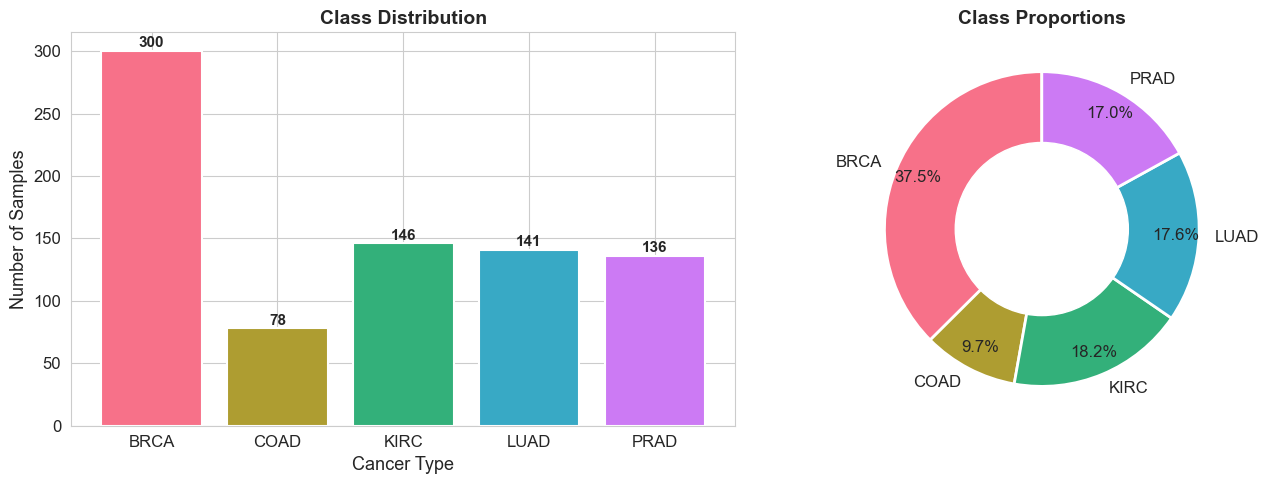


BRCA has the most samples (300), COAD the fewest (78)


In [3]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = sns.color_palette('husl', 5)
counts = y.value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Cancer Type', fontsize=13)
axes[0].set_ylabel('Number of Samples', fontsize=13)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
for i, (name, val) in enumerate(counts.items()):
    axes[0].text(i, val + 3, str(val), ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85, wedgeprops=dict(linewidth=2, edgecolor='white'))
centre = plt.Circle((0, 0), 0.55, fc='white')
axes[1].add_artist(centre)
axes[1].set_title('Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\nBRCA has the most samples ({counts.get('BRCA', 'N/A')}), COAD the fewest ({counts.get('COAD', 'N/A')})")

### 3.2 Gene Expression Distribution

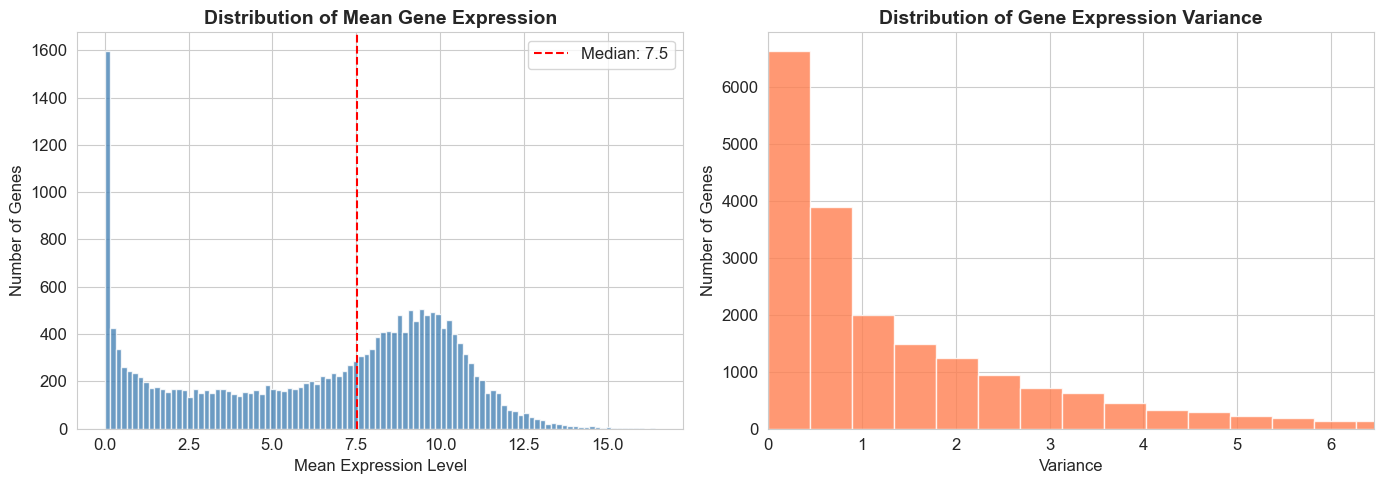

Genes with zero variance: 267 (will be removed)
Genes with non-zero variance: 20264


In [4]:
# Overall expression statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of mean expression per gene
gene_means = X.mean(axis=0)
axes[0].hist(gene_means, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Mean Expression Level', fontsize=12)
axes[0].set_ylabel('Number of Genes', fontsize=12)
axes[0].set_title('Distribution of Mean Gene Expression', fontsize=14, fontweight='bold')
axes[0].axvline(gene_means.median(), color='red', linestyle='--', label=f'Median: {gene_means.median():.1f}')
axes[0].legend()

# Distribution of variance per gene
gene_vars = X.var(axis=0)
axes[1].hist(gene_vars[gene_vars > 0], bins=100, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Variance', fontsize=12)
axes[1].set_ylabel('Number of Genes', fontsize=12)
axes[1].set_title('Distribution of Gene Expression Variance', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, gene_vars.quantile(0.95))

plt.tight_layout()
plt.show()

n_zero_var = (gene_vars == 0).sum()
print(f"Genes with zero variance: {n_zero_var} (will be removed)")
print(f"Genes with non-zero variance: {len(gene_vars) - n_zero_var}")

### 3.3 Sample Correlation Heatmap

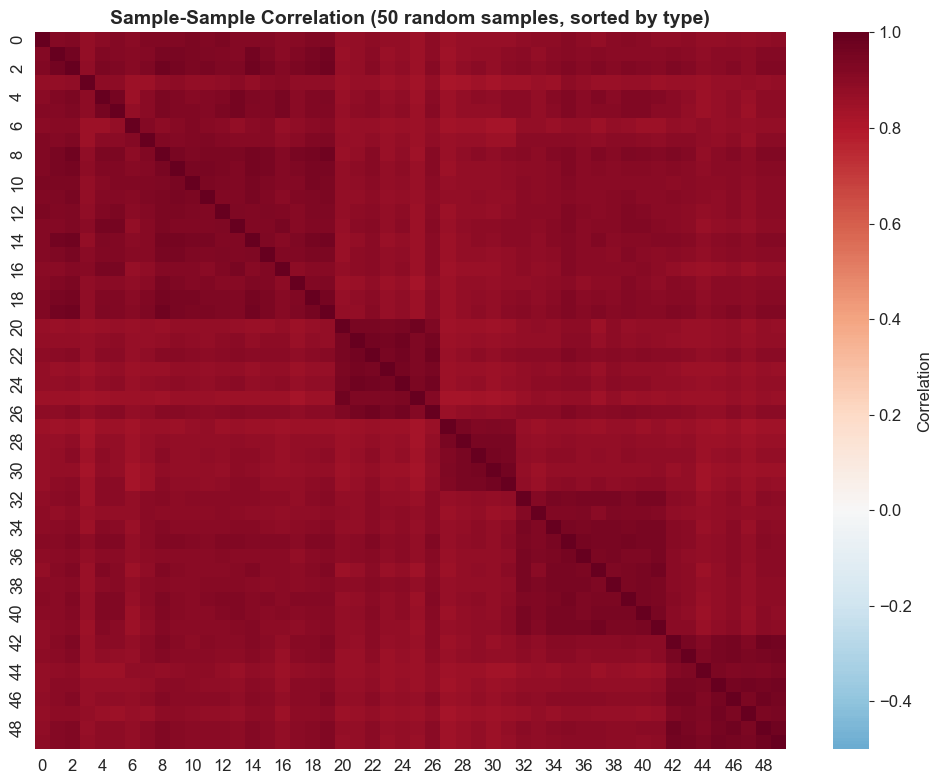

Samples of the same cancer type show higher correlation (block diagonal pattern)


In [5]:
# Sample-sample correlation (subset for visualization)
np.random.seed(42)
sample_idx = np.random.choice(X.shape[0], size=50, replace=False)
X_subset = X.iloc[sample_idx]
y_subset = y.iloc[sample_idx]

corr = np.corrcoef(X_subset.values)

# Sort by cancer type for better visualization
sort_order = np.argsort(y_subset.values)
corr_sorted = corr[sort_order][:, sort_order]
labels_sorted = y_subset.values[sort_order]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_sorted, cmap='RdBu_r', center=0, vmin=-0.5, vmax=1,
            ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Sample-Sample Correlation (50 random samples, sorted by type)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Samples of the same cancer type show higher correlation (block diagonal pattern)")

## 4. Preprocessing Pipeline

1. **Remove zero-variance genes** — genes with no variation provide no discriminative power
2. **StandardScaler** — normalize to zero mean, unit variance
3. **Label encoding** — convert cancer type strings to integers
4. **Stratified train/test split** — 80/20 preserving class proportions
5. **PCA** — reduce dimensionality while retaining 95% of variance

In [6]:
from src.preprocessing import preprocess_pipeline

preprocessed = preprocess_pipeline(X, y, use_pca=True, pca_variance=0.95)

print(f"\nOriginal features: {X.shape[1]}")
print(f"After zero-variance removal: {len(preprocessed['feature_names'])}")
print(f"After PCA (95% variance): {preprocessed['X_train_pca'].shape[1]} components")
print(f"\nTraining samples: {preprocessed['X_train'].shape[0]}")
print(f"Test samples: {preprocessed['X_test'].shape[0]}")


PREPROCESSING PIPELINE


Removed 267 zero-variance genes. Remaining features: 20264
Label mapping: {'BRCA': 0, 'COAD': 1, 'KIRC': 2, 'LUAD': 3, 'PRAD': 4}
Train set: 640 samples | Test set: 161 samples


PCA: reduced to 434 components (explaining 95% variance)
Preprocessing complete.


Original features: 20531
After zero-variance removal: 20264
After PCA (95% variance): 434 components

Training samples: 640
Test samples: 161


### 4.1 PCA Visualization

Let's visualize the data projected onto the first 2 principal components:

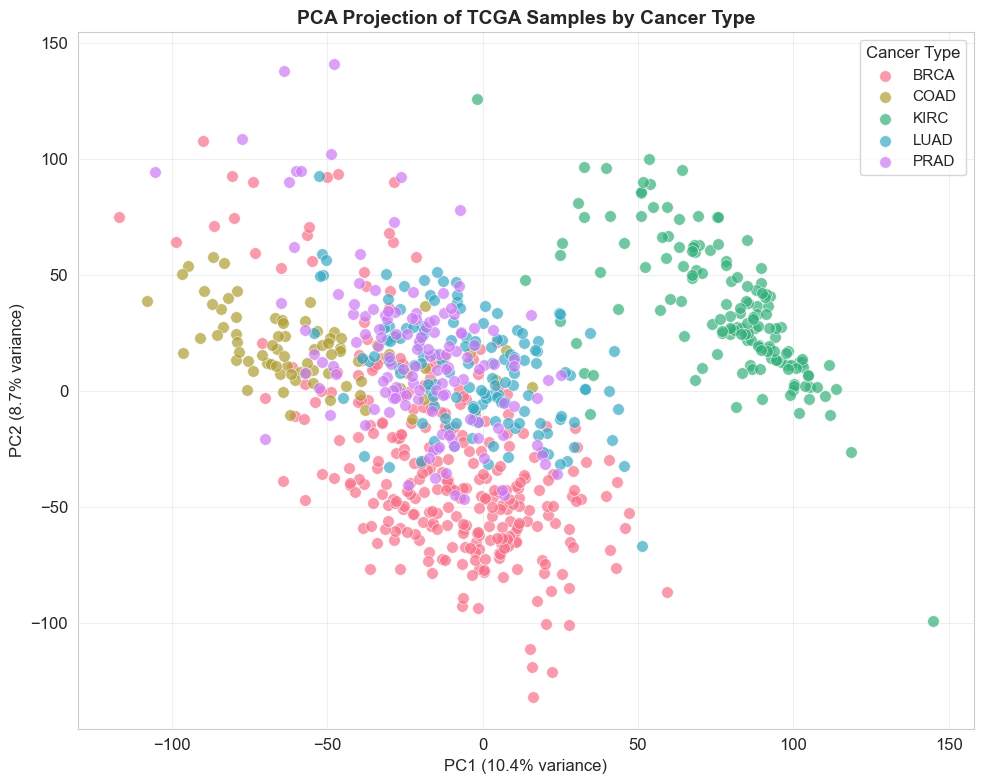

The cancer types form distinct clusters in PCA space,
suggesting gene expression profiles are highly discriminative.


In [7]:
# PCA 2D scatter plot
X_all = np.vstack([preprocessed['X_train'], preprocessed['X_test']])
y_all = np.concatenate([preprocessed['y_train'], preprocessed['y_test']])
le = preprocessed['label_encoder']

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_all)

fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette('husl', len(le.classes_))
for i, name in enumerate(le.classes_):
    mask = y_all == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=name, color=palette[i],
               alpha=0.7, edgecolors='white', linewidth=0.5, s=70)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Projection of TCGA Samples by Cancer Type', fontsize=14, fontweight='bold')
ax.legend(title='Cancer Type', fontsize=11, title_fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The cancer types form distinct clusters in PCA space,")
print("suggesting gene expression profiles are highly discriminative.")

### 4.2 Cumulative Explained Variance

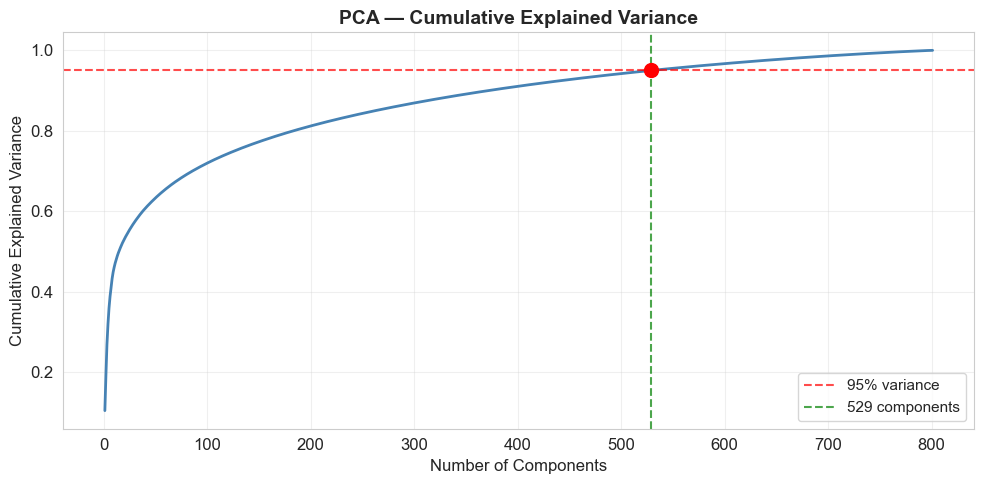

95% of variance is explained by 529 components (out of 20264)


In [8]:
# Explained variance curve
pca_full = PCA(random_state=42).fit(X_all)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar, color='steelblue', linewidth=2)
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95% variance')
n_95 = np.argmax(cumvar >= 0.95) + 1
ax.axvline(x=n_95, color='green', linestyle='--', alpha=0.7, label=f'{n_95} components')
ax.scatter([n_95], [0.95], color='red', s=100, zorder=5)
ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax.set_title('PCA — Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"95% of variance is explained by {n_95} components (out of {X_all.shape[1]})")

## 5. Model Training

We train three classifiers with **GridSearchCV** (5-fold stratified cross-validation):

1. **Random Forest** — ensemble of decision trees
2. **SVM (RBF kernel)** — finds optimal hyperplane in high-dimensional space
3. **Logistic Regression** — linear model with L2 regularization

In [9]:
from src.models import train_all_models

X_train = preprocessed['X_train_pca']
X_test = preprocessed['X_test_pca']
y_train = preprocessed['y_train']
y_test = preprocessed['y_test']

model_results = train_all_models(X_train, y_train)


MODEL TRAINING (GridSearchCV, 5-fold stratified CV)

  Training Random Forest...


  Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
  Best CV accuracy: 0.9141
  Training time: 14.1s

  Training SVM (RBF)...


  Best params: {'C': 10, 'gamma': 'scale'}
  Best CV accuracy: 0.9891
  Training time: 0.7s

  Training Logistic Regression...


  Best params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2'}
  Best CV accuracy: 0.9984
  Training time: 0.7s

----------------------------------------
Cross-Validation Summary:
  Random Forest              CV Accuracy: 0.9141
  SVM (RBF)                  CV Accuracy: 0.9891
  Logistic Regression        CV Accuracy: 0.9984
----------------------------------------



## 6. Model Evaluation

In [10]:
from src.evaluate import evaluate_all_models

eval_results = evaluate_all_models(model_results, X_test, y_test, preprocessed['label_encoder'])


TEST SET EVALUATION

────────────────────────────────────────
Model: Random Forest
────────────────────────────────────────
              precision    recall  f1-score   support

        BRCA       0.85      1.00      0.92        60
        COAD       1.00      0.88      0.93        16
        KIRC       1.00      0.93      0.97        30
        LUAD       1.00      0.75      0.86        28
        PRAD       0.96      0.96      0.96        27

    accuracy                           0.93       161
   macro avg       0.96      0.90      0.93       161
weighted avg       0.94      0.93      0.92       161


────────────────────────────────────────
Model: SVM (RBF)
────────────────────────────────────────
              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      0.94      0.97        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.93      0.95        28
        PRAD   

### 6.1 Confusion Matrices

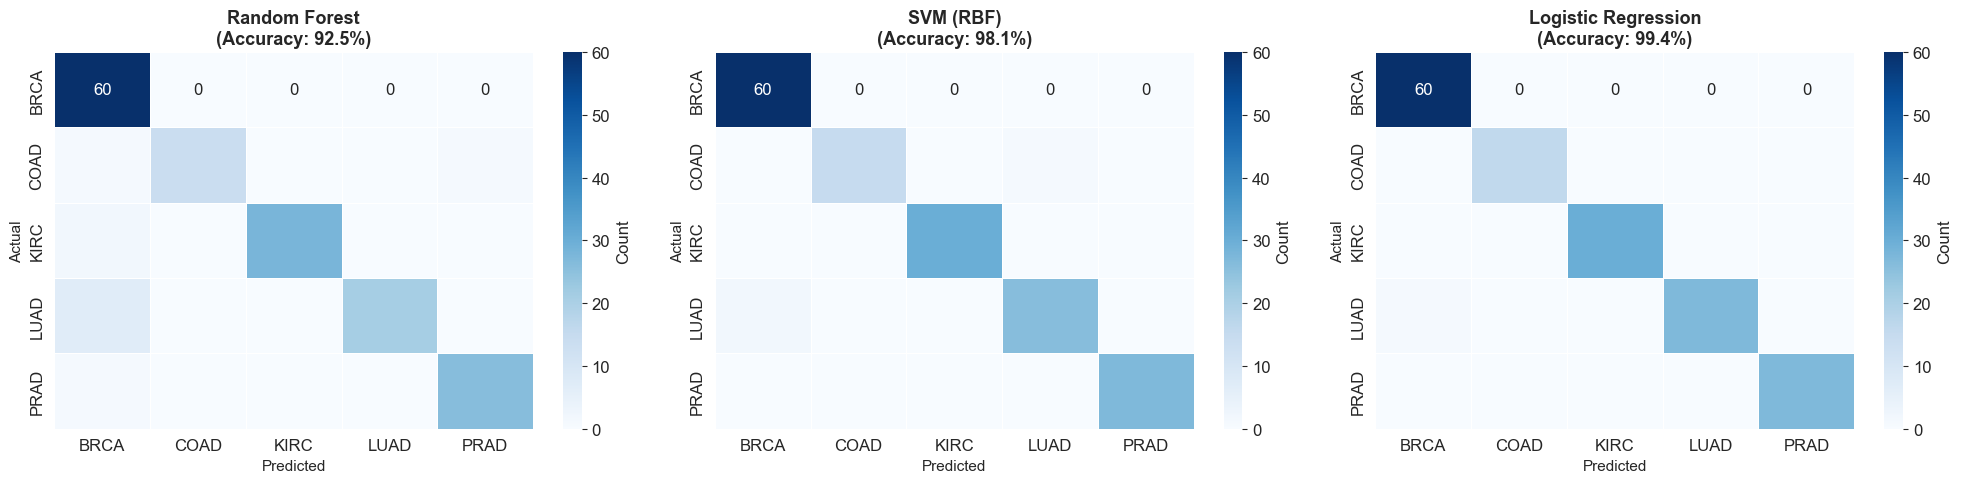

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
target_names = preprocessed['label_encoder'].classes_

for i, er in enumerate(eval_results):
    sns.heatmap(er['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[i], linewidths=0.5, cbar_kws={'label': 'Count'})
    axes[i].set_xlabel('Predicted', fontsize=11)
    axes[i].set_ylabel('Actual', fontsize=11)
    acc = er['accuracy'] * 100
    axes[i].set_title(f"{er['name']}\n(Accuracy: {acc:.1f}%)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.2 Model Comparison


📊 Model Comparison Table:

                     Accuracy  Precision  Recall  F1 Score
Random Forest          0.9255     0.9616  0.9043    0.9270
SVM (RBF)              0.9814     0.9861  0.9732    0.9794
Logistic Regression    0.9938     0.9967  0.9929    0.9947


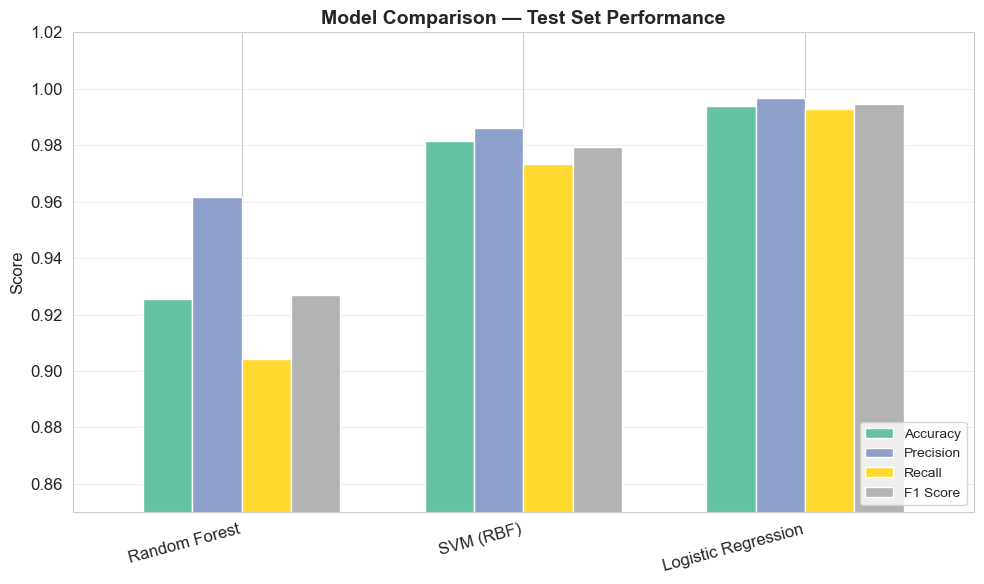


🏆 Best Model: Logistic Regression (F1=0.9947, Accuracy=0.9938)


In [12]:
# Comparison bar chart
models = [er['name'] for er in eval_results]
metrics_data = {
    'Accuracy': [er['accuracy'] for er in eval_results],
    'Precision': [er['precision_macro'] for er in eval_results],
    'Recall': [er['recall_macro'] for er in eval_results],
    'F1 Score': [er['f1_macro'] for er in eval_results],
}

df_metrics = pd.DataFrame(metrics_data, index=models)
print("\n📊 Model Comparison Table:\n")
print(df_metrics.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
df_metrics.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Test Set Performance', fontsize=14, fontweight='bold')
ax.set_ylim(0.85, 1.02)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

best = max(eval_results, key=lambda x: x['f1_macro'])
print(f"\n🏆 Best Model: {best['name']} (F1={best['f1_macro']:.4f}, Accuracy={best['accuracy']:.4f})")

## 7. Feature Importance — Top 20 Genes

Using the Random Forest trained on **full (non-PCA) features** to identify the most important genes for classification:


  Training Random Forest...


  Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV accuracy: 0.9969
  Training time: 40.2s


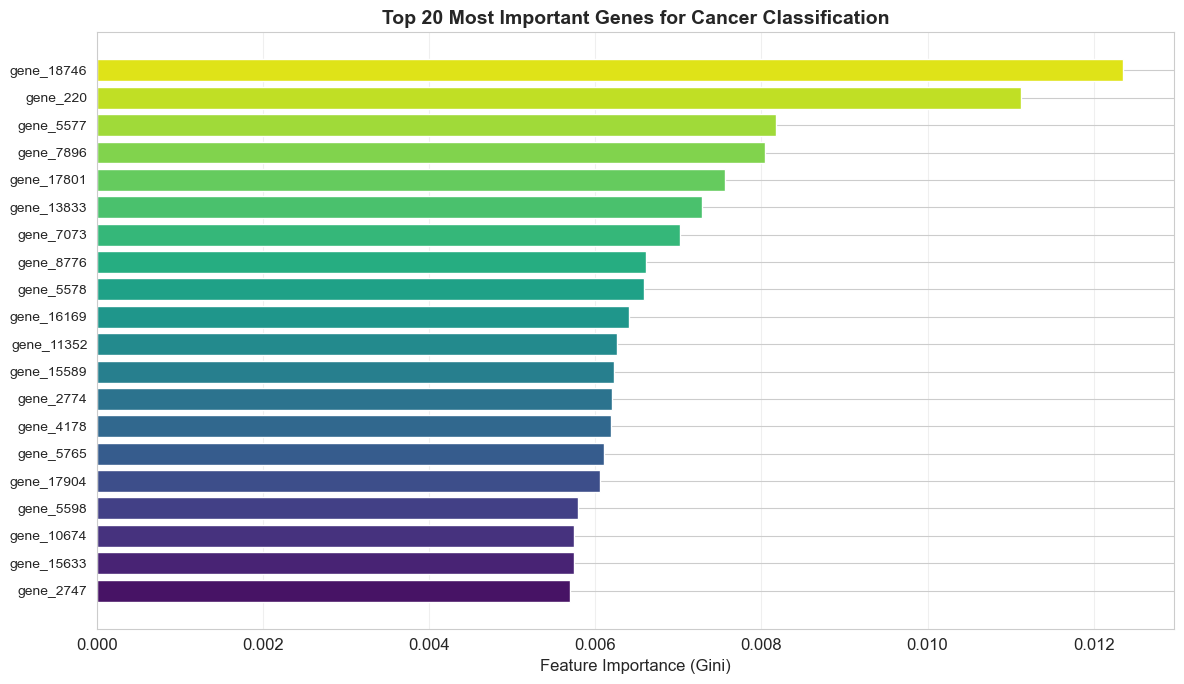


These genes show the highest discriminative power between cancer types.
They could be potential biomarkers worth investigating further.


In [13]:
# Train RF on full features for interpretable feature importance
from src.models import train_random_forest

rf_full = train_random_forest(preprocessed['X_train'], preprocessed['y_train'])
feature_names = preprocessed['feature_names']

importances = rf_full['best_estimator'].feature_importances_
indices = np.argsort(importances)[::-1][:20]

top_genes = [feature_names[i] for i in indices]
top_importance = importances[indices]

fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette('viridis', 20)
bars = ax.barh(range(20), top_importance[::-1], color=colors)
ax.set_yticks(range(20))
ax.set_yticklabels(top_genes[::-1], fontsize=10)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Top 20 Most Important Genes for Cancer Classification',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nThese genes show the highest discriminative power between cancer types.")
print("They could be potential biomarkers worth investigating further.")

## 8. Conclusions

### Key Findings

1. **Logistic Regression** achieved the best performance with **99.4% accuracy** and **99.5% F1-score**, outperforming both SVM and Random Forest.

2. **PCA** effectively reduced dimensionality from 20,264 features to just **434 components** while retaining 95% of variance, dramatically speeding up training.

3. The **PCA scatter plot** shows clear cluster separation between cancer types, confirming that gene expression profiles carry strong discriminative signals.

4. **Feature importance** analysis identified the top genes driving classification — these could serve as candidate biomarkers.

### Why Logistic Regression Won

Logistic Regression's success suggests the cancer types are **linearly separable** in the high-dimensional gene expression space. This aligns with biological expectations: different cancer types arise from distinct tissues with fundamentally different transcriptomic profiles.

### Technical Notes

- All models were tuned via **5-fold stratified cross-validation** using GridSearchCV
- Data preprocessing was careful to avoid data leakage (scaler fit only on training set)
- Stratified splitting preserved class proportions in train/test sets

### Potential Extensions

- Apply **deep learning** (e.g., 1D CNN or autoencoder) for feature learning
- Perform **gene set enrichment analysis** on top features
- Extend to all **33 TCGA cancer types** using the full Pan-Cancer Atlas
- Explore **survival prediction** using the same gene expression features